# Combining branching processes and Allee effects into an integral projection model to assess invasion risk
James P. Peirce Cynthia S. Tam Joseph J. Parkos Grace L. Loppnow Mark W. Fritts Alison A. Coulter Richard A. Erickson

This is a Jupyter notebook utlizing the model defined in the paper.

# Setup of Python Environment

The notebook uses Python libraries:

In [1]:
import numpy as np
import pandas as pd
#import seaborn as sns
import scipy.stats as stats
import plotnine as p9
from scipy.special import expit
from random import choices, random 
import IPython

Next, as well as custom functions within their own module:

In [ ]:
import IPMbpA as ipma

# Application to Silver Carp
Silver carp are planktivorous fish native to freshwater systems in eastern Asia, with a range
extending from Russia to China and potentially northern Vietnam. Due to their role as lower trophic-level filter feeders, 
Silver carp were introduced to the United States in the 1970s for aquaculture, plankton control, and sewage treatment applications. 
Escapes from aquaculture facilities in the 1990s facilitated their establishment in the Mississippi River Basin, 
including the Illinois River. Their continued expansion poses a significant threat to the Great Lakes, as the Illinois River is hydrologically connected to Lake
Michigan. Concerns about the potential ecological and economic consequences of their introduction
into the Great Lakes have prompted widespread societal attention, given the anticipated direct and
indirect impacts on native fish species and the broader ecosystem. Likewise, the species continues to spread throughout the Mississippi River Basin, including headwaters and
tributaries.

## Length Mesh 

In [3]:
min_len = 0.01
max_len = 1.5 
n_len = 50 # number of length bins
length_mesh = np.linspace(min_len, max_len, n_len)
delta_z = np.diff(length_mesh)[0] # width of length bin

### Survival
The model was estimated using Lorenzen's (1996) relationship between body weight and natural mortality.  
We convert length to weight using $\log_{10}$-$\log_{10}$ length-weight estimates from Erickson et al. (2021) for Silver Carp.
We used an intercept of 1.02 and slope of 3.02, picking the highest values because values were highest near the invasion front:

In [4]:
svcp_lw = ipma.length_weight(intercept = 1.02, slope = 3.02)
p_survive = ipma.prob_survival(lw_func = svcp_lw, slope = 3.30, exponent = -0.261)

### Growth

The growth function is taken from the MetaIPM package's node [function](https://code.usgs.gov/umesc/quant-ecology/metaipm/-/blob/v1.0.0/MetaIPM/node.py).
This maps length at the current timestep, $z$, to lengths at the next time step, $z^\prime$:

In [5]:
von_b_growth = ipma.node(vonB_Linf = 1.224, vonB_K = 0.173, vonB_sigma_k = 0.1)

### Maturity

Next, we look at the probabiltiy of maturity as function of length.
This uses a class from `ipma`.
The parameter values are from Erickson et al. (2021):

In [6]:
svcp_mat = ipma.mature(intercept = -7.41, slope = 24.98)

#### Fish Size
-   Large Adult (z = 1.0 m) 
-   Subadults of age 1 (z = 0.3177 m)

With biomass:

In [7]:
print("Biomass of 1 m fish:", round(svcp_lw.predict_weight(1.0),2),"kg")
print("Biomass of 0.3177 m fish:", round(svcp_lw.predict_weight(0.3177),2),"kg")

Biomass of 1 m fish: 10.47 kg
Biomass of 0.3177 m fish: 0.33 kg


### Allee model parameters 
Assume a very large carrying capacity K (and not worry about being above carry capacity).
Interest in examining various Allee thresholds Cs.

In [8]:
gamma_Allen = 1.837
C_low = 10.47*1  # kg = one 1 m fish 
C_mid = 10.47*10  # kg = ten 1 m fish
C_high = 10.47*100  # kg = 100 1 m fish
K = 10.47*500
gamma = gamma_Allen/K

## Single Simulation

### Simulation Settings

In [52]:
# Initial number of fish
n0_fish_adult = 10
adult_fish_len = 1.0
#
n0_fish_subadult = 320
subadult_fish_len = 0.3177
# Allee Threshold
C = C_mid
# Years to simulate
n_time = 50 # consistent with Cuddington et al. (2013)

### Model Run

In [ ]:
import importlib
importlib.reload(ipma)

out = ipma.ipm_bp_allee(
    p_survive = p_survive,
    p_mature = svcp_mat,
    lw_input = svcp_lw,
    gamma = gamma,
    C = C,
    K = K,
    k = 1,
    min_len = 0.01,
    max_len = 1.5,
    n_len = n_len,
    n_time = n_time,
    length_mesh = None,
    growth_matrix = von_b_growth.growth(length_now = length_mesh, length_next = length_mesh),
    yoy_mean = 0.319,
    yoy_sd = 0.040,
    init_pop = { "initial population": np.array([n0_fish_adult]),
                 "length (m)": np.array([adult_fish_len])})

### Graphs

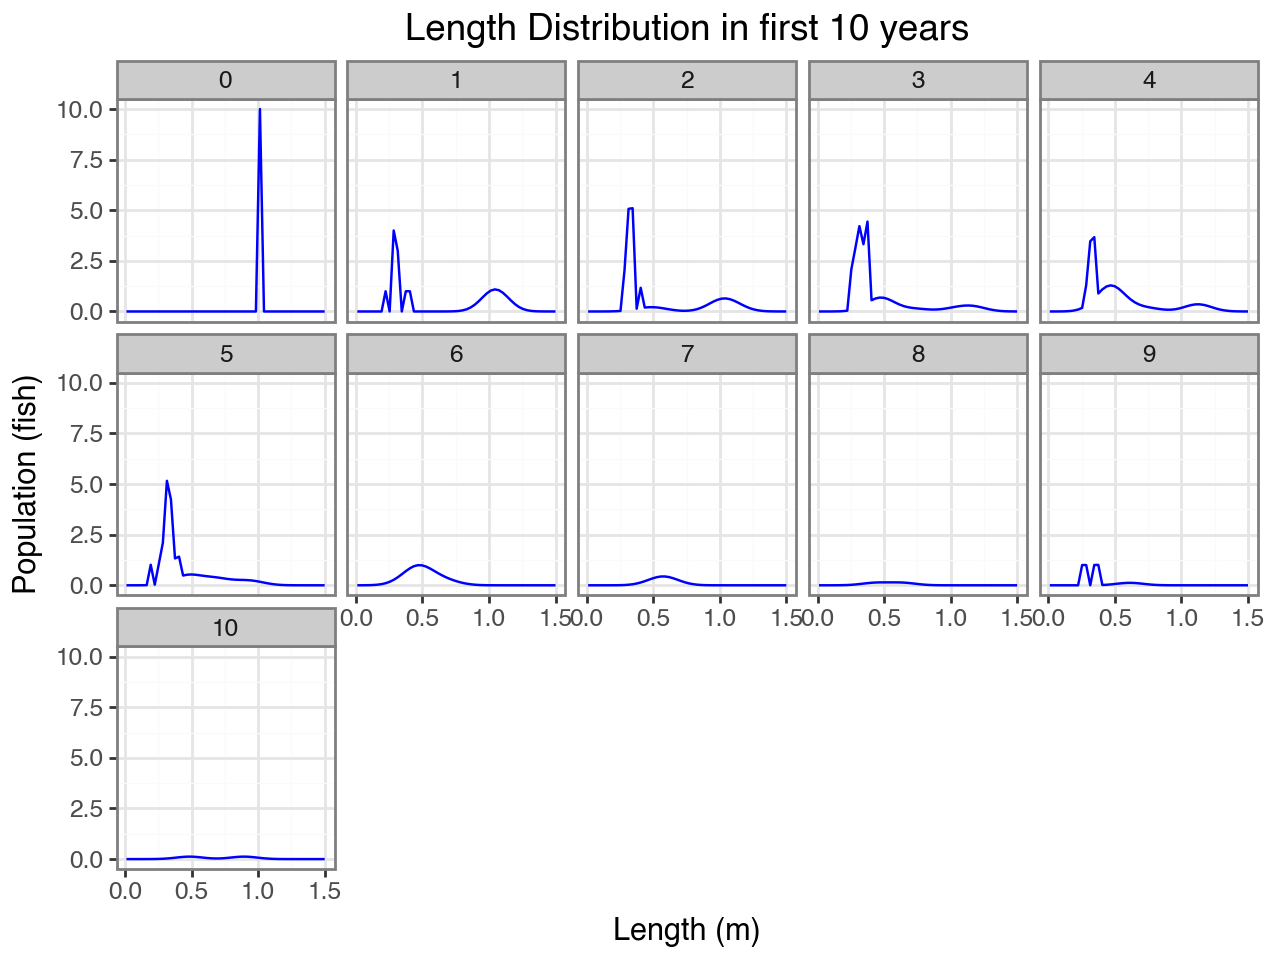

In [11]:
total_pop = pd.DataFrame(out) * delta_z
total_pop["Length"] = length_mesh
total_pop_long = total_pop.melt(id_vars="Length", var_name="Year", value_name="Population")

# Filter the data for the first 10 years
total_pop_long_10_years = total_pop_long[total_pop_long['Year'].astype(int) <= 10]

# Initialize the FacetGrid object
plot = (
    p9.ggplot(total_pop_long_10_years, p9.aes(x="Length", y="Population")) +
    p9.geom_line(color='blue') +
    p9.facet_wrap('~Year', ncol=5) +
    p9.theme(subplots_adjust={'wspace': 0.25, 'hspace': 0.25}) +
    p9.labs(x="Length (m)", y="Population (fish)", title="Length Distribution in first 10 years") +
    p9.theme_bw()
)
plot.show()

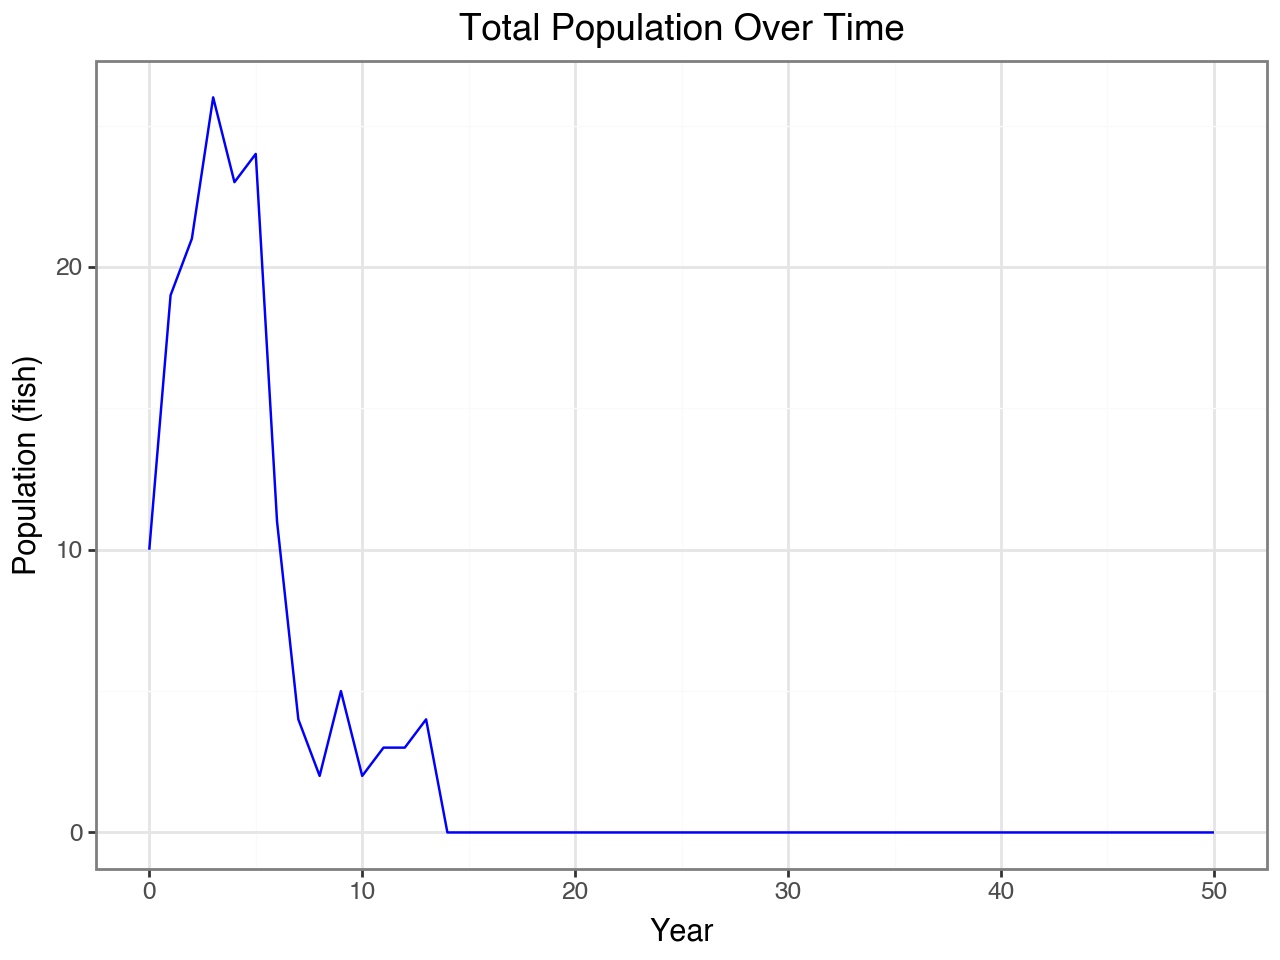

In [12]:
total_pop_sum = total_pop_long.groupby("Year").aggregate(["sum"]).drop(axis=1, labels="Length")
total_pop_sum.columns = total_pop_sum.columns.droplevel(1)
total_pop_sum = total_pop_sum.reset_index()

# Create the plot
plot = (
    p9.ggplot(total_pop_sum, p9.aes(x="Year", y="Population")) +
    p9.geom_line(color='blue') +
    p9.theme(subplots_adjust={'wspace': 0.25, 'hspace': 0.25})+
    p9.labs(x="Year", y="Population (fish)", title="Total Population Over Time") +
    p9.theme_bw()
)
plot.show()

## Many Simulations - Figure 1
**Note:** May take approximately 3-5 minutes to run 1000 simulations.

Sample paths and the mean (+/- SE) of the stochastic model for an initial biomass of
female Silver carp (10 adult, 320 subadult fish, 10 subadult fish) with an Allee biomass threshold of 10 adult ≈
320 subadult fish. The stochastic mean is shown as a function of time (dashed curve), alongside five sample paths
of the stochastic model (solid curves). The dotted curve represents the threshold. (b), (d), and (f): Histograms
approximating the frequency distribution of the stochastic model at t = 50, with bin widths of 200 fish.

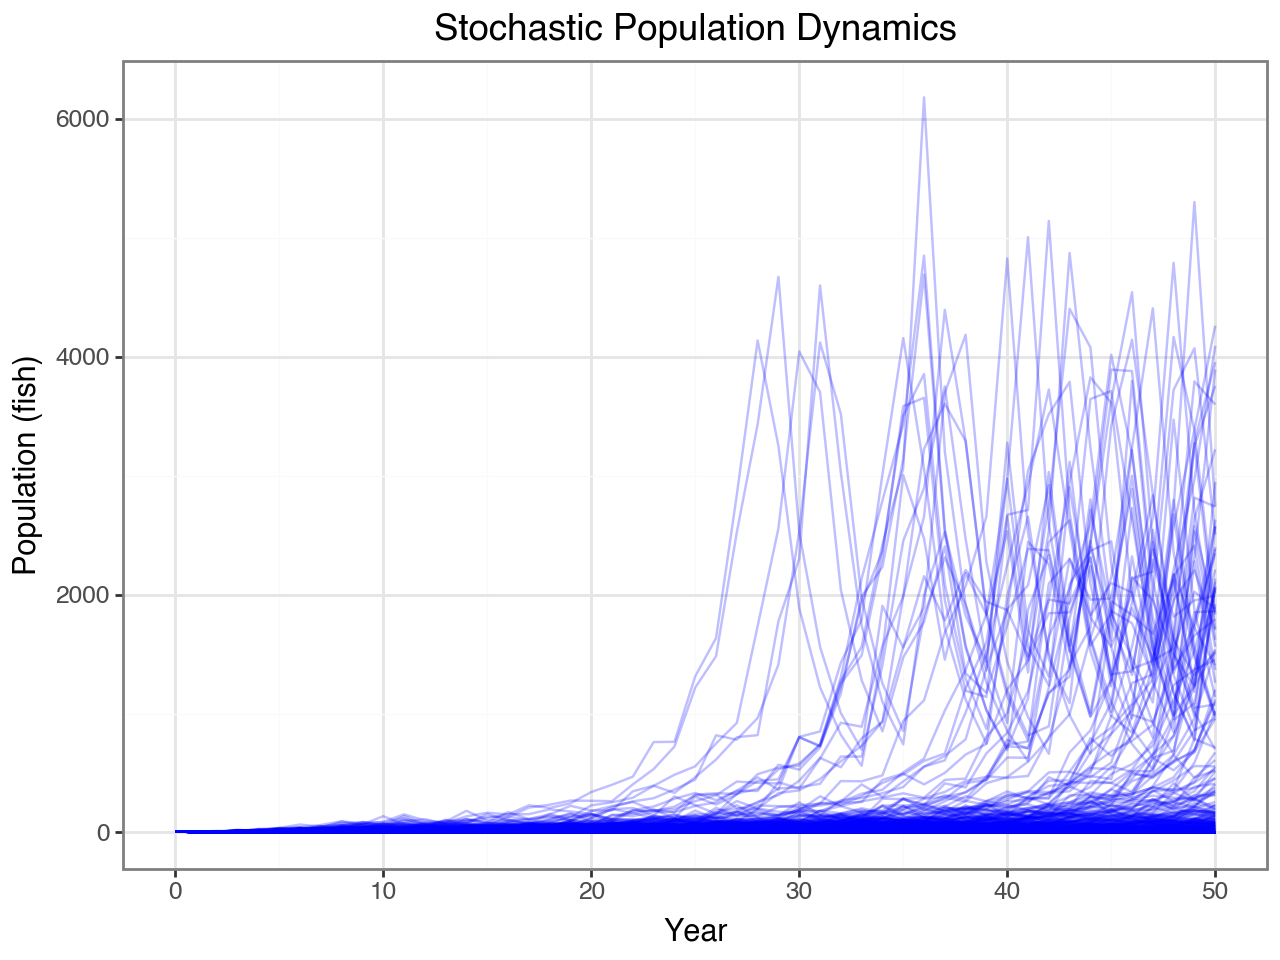

In [67]:
import importlib
importlib.reload(ipma)

out = ipma.stoch_wrapper(
    p_survive = p_survive,
    p_mature = svcp_mat,
    lw_input = svcp_lw,
    gamma = gamma,
    C = C,
    K = K,
    k = 2,
    min_len = min_len,
    max_len = max_len,
    n_len = n_len,
    n_time = n_time,
    n_iter = 1000,
    length_mesh = length_mesh,
    growth_matrix = von_b_growth.growth(length_now = length_mesh, length_next = length_mesh),
    yoy_mean = 0.319,
    yoy_sd = 0.040,
    init_pop = { "initial population": np.array([n0_fish_adult]), "length (m)": np.array([subadult_fish_len])})

out = out.reset_index()
plot = (
    p9.ggplot(out, p9.aes(x="Year", y="Population", group="iter")) +
    p9.geom_line(alpha=0.25, color='blue') +
    p9.theme(figure_size=(6, 4))+
    p9.labs(x="Year", y="Population (fish)", title="Stochastic Population Dynamics") +
    p9.theme_bw()
)
plot.show()


### Sample 5 iterations

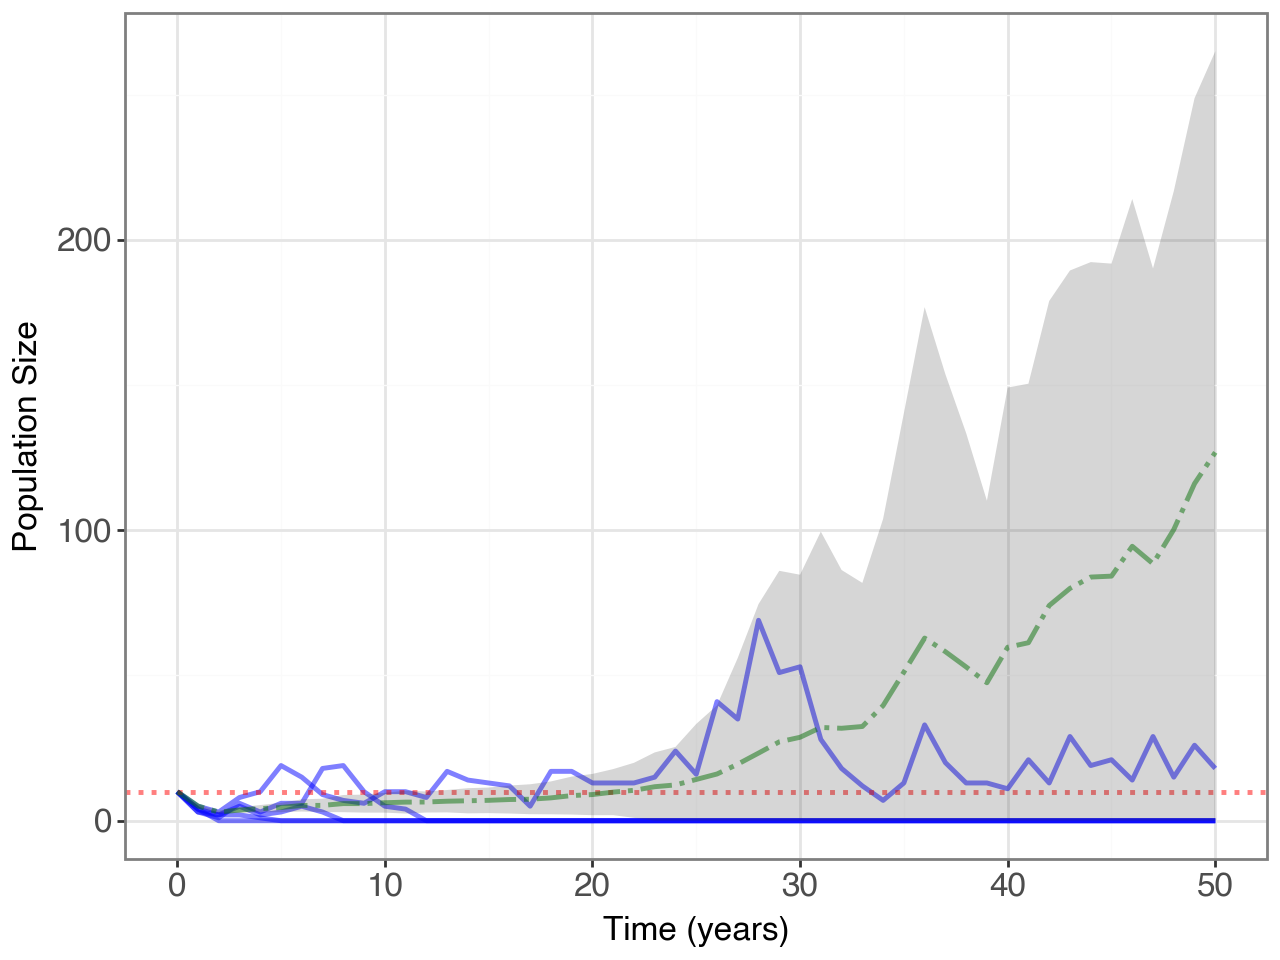

In [83]:
sampled_iters = out['iter'].sample(n=5, random_state=4).unique()

# Filter the data for the sampled iterations
sampled_data = out[out['iter'].isin(sampled_iters)]

# Calculate the mean and standard deviation for each time point
mean_population = out.groupby('Year')['Population'].mean().reset_index()
sd_population = out.groupby('Year')['Population'].std().reset_index()

# Calculate the 95% prediction interval
mean_population['lower'] = np.maximum(0, mean_population['Population'] - 1.96 * sd_population['Population'] / np.sqrt(len(out['Year'].unique())))
mean_population['upper'] = mean_population['Population'] + 1.96 * sd_population['Population'] / np.sqrt(len(out['Year'].unique()))


# Create the plot
plot = (
    p9.ggplot(sampled_data, p9.aes(x="Year", y="Population", group="iter")) +
    p9.geom_line(alpha=0.5, color='blue', size = 1) +
    p9.geom_hline(yintercept=n0_fish_adult, linetype='dotted', color='red', alpha=0.5, size=1) +
    p9.geom_line(mean_population, p9.aes(x="Year", y="Population"), linetype='dashdot', color='green', alpha=0.5, size=1) +
    p9.geom_ribbon(mean_population, p9.aes(ymin='lower', ymax='upper'), alpha=0.2) +
    p9.scale_y_continuous(labels=lambda x: [f"{val:,.0f}" for val in x]) +  # Format y-axis with commas for thousands
    p9.theme(figure_size=(6, 4)) +
    p9.theme_bw() +
    p9.theme(axis_text_x=p9.element_text(size=12),  # Increase x-axis tick label size
             axis_text_y=p9.element_text(size=12),
             axis_title_x=p9.element_text(size=12), 
             axis_title_y=p9.element_text(size=12)) +  # Increase y-axis tick label s
    p9.labs(
        #title="Population Dynamics with Initial Population and Mean Population",
        x="Time (years)",
        y="Population Size"
    )
)

plot.show()


In [72]:
#plot.save("figures/pop_n0isC_adult.png", dpi=300)
#plot.save("figures/pop_n0isC_juv.png", dpi=300)
plot.save("figures/pop_n0isadult_juv.png", dpi=300)

/Users/jpeirce/miniconda3/lib/python3.10/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/jpeirce/miniconda3/lib/python3.10/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: figures/pop_n0isadult_juv.png


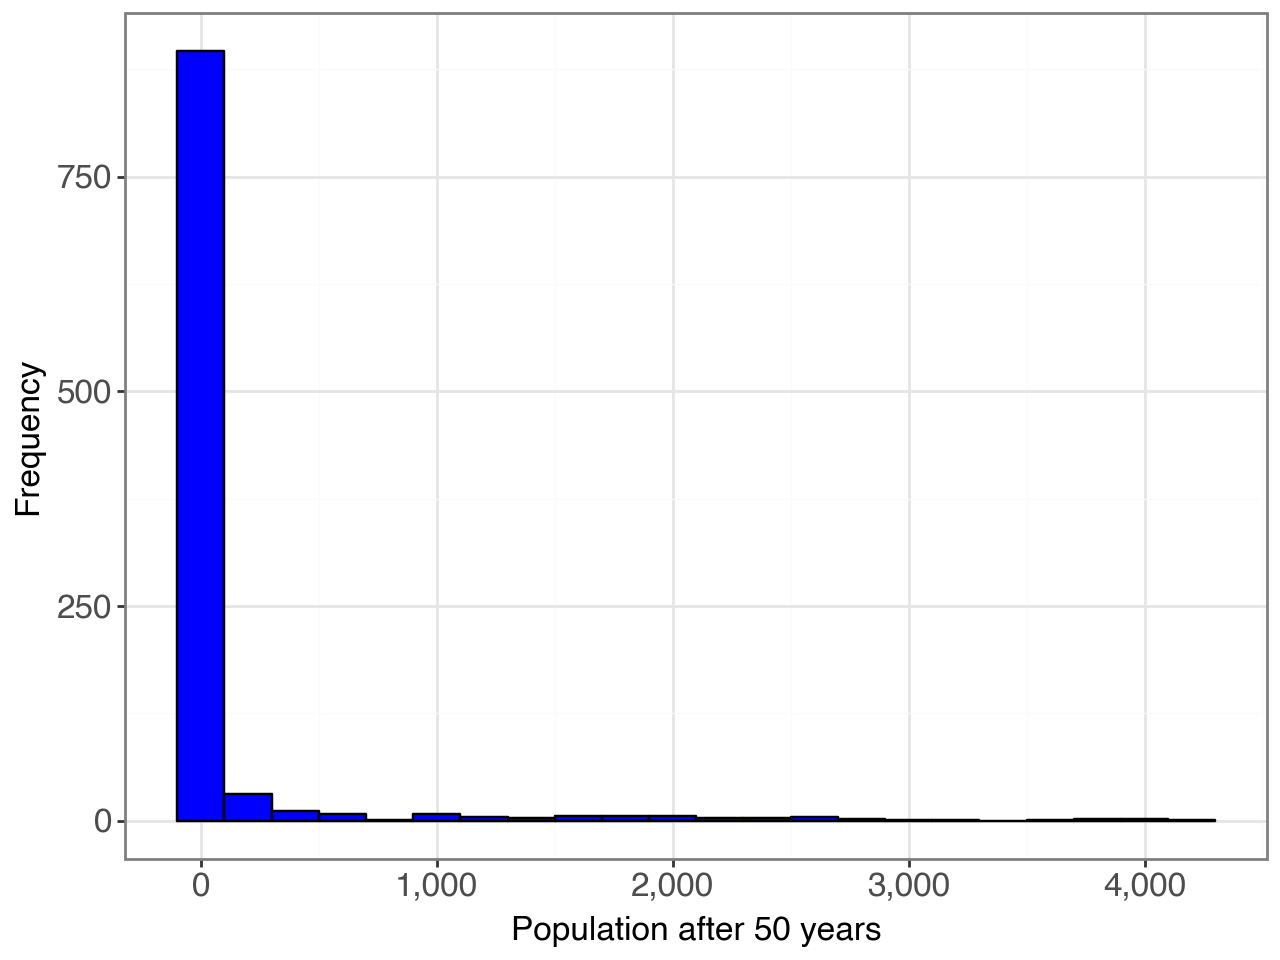

invasion
established        182
non-established    818
dtype: int64


In [73]:
# Extract the population at time n_time for each iteration
population_at_end = out[out['Year'] == n_time][['iter', 'Population']]

plot = (
    p9.ggplot(population_at_end, p9.aes(x="Population")) +
    p9.geom_histogram(binwidth=200.0, fill='blue', color = "black") +
    p9.scale_x_continuous(labels=lambda x: [f"{val:,.0f}" for val in x]) +  # Format y-axis with commas for thousands
    p9.theme(figure_size=(6, 4)) +
    p9.theme_bw() +
    p9.theme(axis_text_x=p9.element_text(size=12),  # Increase x-axis tick label size
             axis_text_y=p9.element_text(size=12),
             axis_title_x=p9.element_text(size=12), 
             axis_title_y=p9.element_text(size=12)) +  # Increase y-axis tick label s

    p9.labs(
      #  title="Histogram of Population Size after 50 years",
        x="Population after 50 years",
        y="Frequency"
    ) 
)
plot.show()

plot_bw = (
    p9.ggplot(population_at_end, p9.aes(x="Population")) +
    p9.geom_histogram(binwidth=200.0, color = "black") +
    p9.labs(
      #  title="Histogram of Population Size after 50 years",
        x="Population after 50 years",
        y="Frequency"
    ) +
    p9.theme_bw()
)
#plot_bw.show()

#out_condlist = [population_at_end["Population"] >= 1000,
#                  population_at_end["Population"] < 1000]
out_condlist = [population_at_end["Population"] > 10,
                  population_at_end["Population"] <= 10 ]
choicelist = ["established", "non-established"]
population_at_end["invasion"] = np.select(out_condlist, choicelist, default="")
print(population_at_end.groupby("invasion").size())


In [74]:
#plot.save("figures/pop50_n0isC_adult.png", dpi=300)
#plot.save("figures/pop50_n0isC_juv.png", dpi=300)
plot.save("figures/pop50_n0isadult_juv.png", dpi=300)


/Users/jpeirce/miniconda3/lib/python3.10/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/jpeirce/miniconda3/lib/python3.10/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: figures/pop50_n0isadult_juv.png


## Probability of Establishment - Figure 2a
Probability of establishing a population of 1,000 female fish in 20 years, calculated from 100 replicate
simulations, versus the number of adult female fish that breach containment on one occasion for 10, 50, and 100 adult
fish Allee threshold, respectively. 

### Simuation Settings:

In [84]:
n_time = 20
C = 10.47*10
C_low = 10.47*10
C_mid = 10.47*50
C_high = 10.47*100

### Model Run
**Note:** May take approximately 4-7 minutes to run 50 simulations.

In [85]:
import importlib

importlib.reload(ipma)

# Define the values of C
C_values = [C_low, C_mid, C_high]
C_labels = ["C=10", "C=50", "C=100"]
line_styles = ['dotted', 'dashed', 'solid']
markers = ['^', 's', 'o']

colorblind_palette = ["#E69F00", "#56B4E9", "#009E73"]

# Initialize a list to store the results
results = []

# Loop through each value of C
for C, label, line_style, marker in zip(C_values, C_labels, line_styles, markers):
    prob_establishment_values = []
    for n0_fish in np.arange(1, 132, 5): # for adults
#    for n0_fish in np.arange(30, 1530, 100): # for juv
        out = ipma.stoch_wrapper(
            p_survive = p_survive,
            p_mature = svcp_mat,
            lw_input = svcp_lw,
            gamma = gamma,
            C = C,
            K = K,
            k = 2,
            min_len = min_len,
            max_len = max_len,
            n_len = n_len,
            n_time = n_time,
            n_iter = 50,
            length_mesh = length_mesh,
            growth_matrix = von_b_growth.growth(length_now = length_mesh, length_next = length_mesh),
            yoy_mean = 0.319,
            yoy_sd = 0.040,
            init_pop = { "initial population": np.array([n0_fish]), "length (m)": np.array([1.0])})

        out = out.reset_index()

        # Extract the population at time n_time for each iteration
        population_at_end = out[out['Year'] == n_time][['iter', 'Population']]

        out_condlist = [population_at_end["Population"] >= 1000,
                        population_at_end["Population"] < 1000]
        choicelist = ["established", "non-established"]
        population_at_end["invasion"] = np.select(out_condlist, choicelist, default="")

        prob_establishment = population_at_end["invasion"].value_counts().get("established", 0)/len(population_at_end)
        prob_establishment_values.append(prob_establishment)

    # Store the results in a DataFrame
    results.append(pd.DataFrame({
        'n0_fish': np.arange(1, 132, 5),
    #    'n0_fish': np.arange(30, 1530, 100),
        'prob_establishment': prob_establishment_values,
        'C': label,
        'line_style': line_style,
        'marker': marker,
        'fill_style': 'none'
    }))

# Concatenate all results into a single DataFrame
results_df = pd.concat(results)


### Graphs

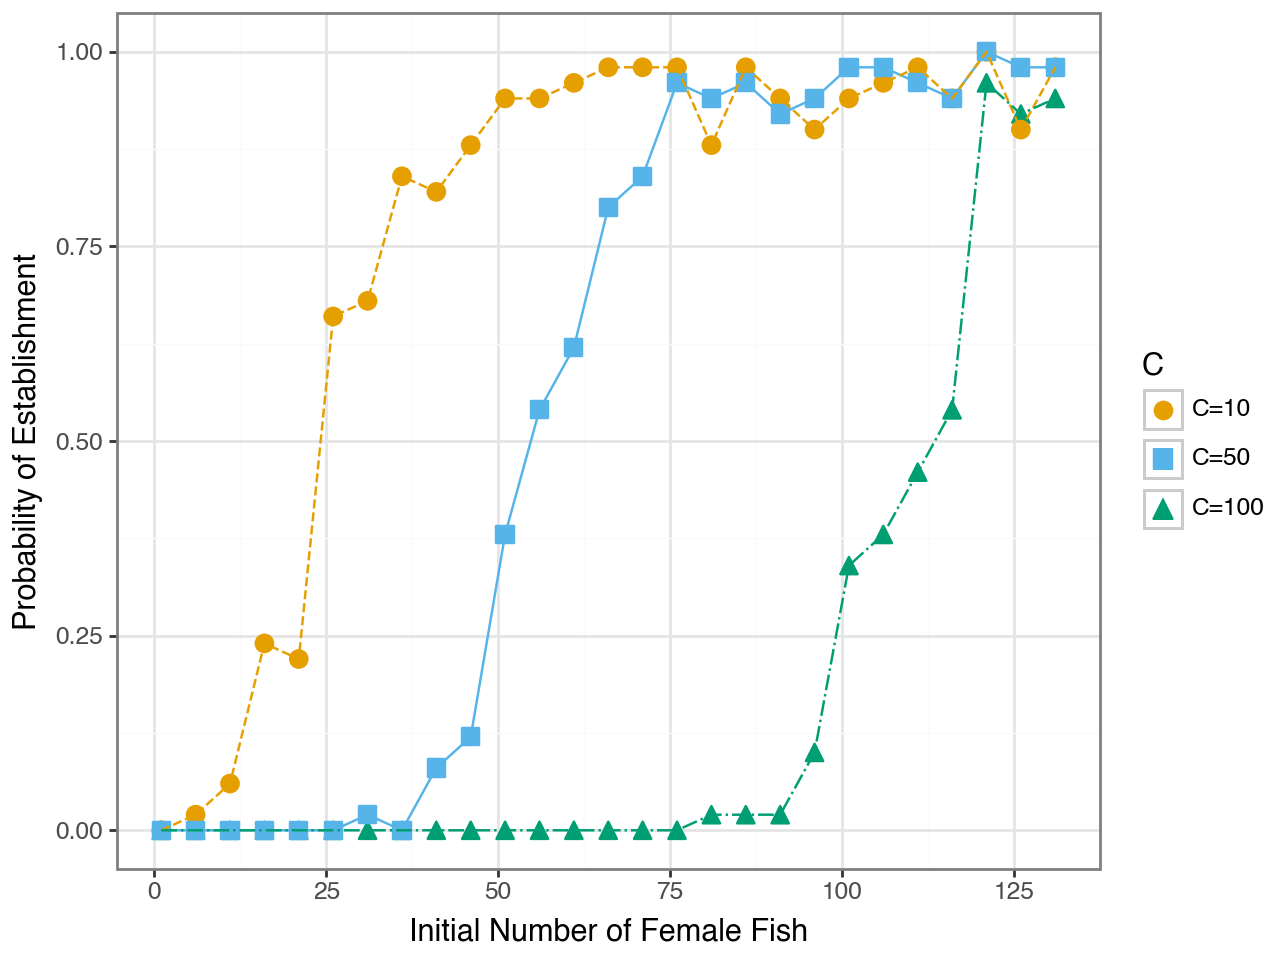

In [87]:

# Assuming the unique values are integers or strings without "C="
# Convert the 'C' column to a categorical type with specified levels
results_df['C'] = pd.Categorical(results_df['C'], categories=["C=10", "C=50", "C=100"], ordered=True)

# Define colorblind_palette and markers if not already defined
#colorblind_palette = ["#0072B2", "#D55E00", "#009E73"]  # Example colors
colorblind_palette = ["#E69F00", "#56B4E9", "#009E73"]
markers = ["o", "s", "^"]  # Example markers

# Plot the results
plot = (
    p9.ggplot(results_df, p9.aes(x='n0_fish', y='prob_establishment', color='C', shape='C')) +
    p9.geom_point(size=3, show_legend=True) +
    p9.geom_line(p9.aes(linetype='line_style'), show_legend=False) +
    p9.scale_color_manual(values=colorblind_palette, breaks=["C=10", "C=50", "C=100"], labels=['C=10', 'C=50', 'C=100']) +
    p9.scale_shape_manual(values=markers, breaks=["C=10", "C=50", "C=100"], labels=['C=10', 'C=50', 'C=100']) +
    p9.labs(
        x="Initial Number of Female Fish",
        y="Probability of Establishment"
    ) +
    p9.ylim(0, 1.0) +
    p9.scale_x_continuous(breaks=range(0, int(results_df['n0_fish'].max()) + 25, 25)) +  # Set x-axis ticks every 25
    p9.theme(legend_title=p9.element_blank(),
             axis_title_x=p9.element_text(size=12), 
             axis_title_y=p9.element_text(size=12))+
    p9.theme_bw() 
)

plot.show()

In [88]:
plot.save("figures/probE_adult.png", dpi=300)

/Users/jpeirce/miniconda3/lib/python3.10/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/jpeirce/miniconda3/lib/python3.10/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: figures/probE_adult.png


## Time to Establishment - Figure 2b

Mean time in years to establish a population of 1,000 adult female fish (±1 SD) following a one time containment breach of a number of adult fish (assume equal number of males), where either the Allee threshold is 10, 50, or 100 adult fish.

In [92]:
class length_weight:
    '''
    Define log-10 length-weight class
    '''
    def __init__(self, intercept = 1.02, slope = 3.02):
        self.intercept = intercept
        self.slope = slope
    
    def predict_weight(self, length):
        weight = 10.0 ** (self.intercept + self.slope * np.log10(length))
        return(weight)
    
class prob_survival:
    '''
    Define surival as a function of length.
    '''
    def __init__(self, lw_func, slope = 2.7, exponent = -0.315):
        self.slope = slope
        self.exponent = exponent,
        self.lw_func = lw_func
    def prob_s(self, length):
        weight = self.lw_func.predict_weight(length) * 1000
        ## 1000 converts from kg to g
        survival = 1.0 - (1.0 - np.exp(- self.slope * weight ** (self.exponent)))
        return survival

class node:
    '''
    This is from the MetaIPM package.
    We hope to someday intergrate this model into that model.
    '''
    def __init__(self, vonB_Linf, vonB_K, vonB_sigma_k):
        self.vonB_Linf = vonB_Linf
        self.vonB_K = vonB_K
        self.vonB_sigma_k = vonB_sigma_k

    def growth(self, length_now, length_next):
        z = np.atleast_1d(length_now)
        z_prime = np.atleast_1d(length_next)

        project = np.zeros((len(z), len(z_prime)))
        for index in range(0, len(z)):
            location_parameter = np.exp(- self.vonB_K) * z[index] + \
                (1-np.exp(-self.vonB_K)) * self.vonB_Linf
            prob_raw = stats.norm.pdf(x=z_prime,
                                      loc=location_parameter,
                                      scale=self.vonB_sigma_k)
            project[index, :] = prob_raw / prob_raw.sum()
        return project
    
class mature():
    def __init__(self, intercept = -7.41, slope = 24.98):
        self.mat_alpha = intercept
        self.mat_beta = slope
    def maturity_prob(self, length_in):
        return expit(self.mat_alpha + self.mat_beta * length_in)

def grow_select(growth_matrix, pop_vec_in):
    # Extract growth probs
    grow_pop_pos = growth_matrix[np.where(pop_vec_in > 0)[0], :] # selects all growth columns where pop>0
    # Create array to hold outputs
    new_pop_array = np.zeros(grow_pop_pos.shape[1])
  #  delta_z = np.diff(length_mesh)[0]

    # Loop through growth columns
    for g_idx in range(grow_pop_pos.shape[0]):
        # select new growth bins
        new_pop_array += np.random.multinomial(pop_vec_in[pop_vec_in>0][g_idx], grow_pop_pos[g_idx])
    return new_pop_array


In [93]:
def ipm_bm_allee_time(
    p_survive,
    p_mature,
    lw_input,
    gamma,
    C,
    K,
    k,
    min_len,
    max_len,
    n_len,
    n_time,
    n_iter,
    length_mesh,
    growth_matrix,
    yoy_mean,
    yoy_sd,
    init_pop):
    if length_mesh is None:
        length_mesh = np.linspace(min_len, max_len, n_len)

    if growth_matrix is None:
        growth_matrix = von_b_growth.growth(length_now = length_mesh, length_next = length_mesh)
        
    delta_z = np.diff(length_mesh)[0] # width of length bin
    # Convert input lengths to mesh bins
    bins = np.digitize(init_pop["length (m)"], length_mesh, right=True)
    pop_dens = np.zeros([n_len, n_time + 1])
    # for needed if multiple lengths in same bin
    for idx in range(len(bins)):
        pop_dens[bins[idx], 0] += init_pop["initial population"][idx]
    # Normalize to ensure the sum equals the initial population
    pop_dens[:, 0] *= init_pop["initial population"].sum() / (pop_dens[:, 0] * delta_z).sum()

    yoy_place_raw = stats.norm.pdf(x=length_mesh,
                               loc=yoy_mean,
                               scale=yoy_sd)
    yoy_place_den = yoy_place_raw/yoy_place_raw.sum() 
    # create initial condition
      
    for t_idx in range(n_time):
        if (pop_dens[:,t_idx].sum()*delta_z) > 1000:
            return pop_dens
        else:        
            biomass_t = (lw_input.predict_weight(length_mesh) * pop_dens[:, t_idx] * delta_z).sum()
            biomass_tp1 =  biomass_t*np.exp(gamma*(1-biomass_t/K)*( (biomass_t-C)))
            pop_mat_dens = np.array([stats.binom.rvs(n = 1,
                            p = p_mature.maturity_prob(xx),
                            loc=0, size = int(pop_dens[xx, t_idx]),
                            random_state=None).sum() for xx in range(n_len)])
            mature_total = (pop_mat_dens*delta_z).sum() #m_t
            surv_dens =  np.array([stats.binom.rvs(n = 1,
                     p = p_survive.prob_s(length_mesh[xx]),
                     loc=0, size = int(pop_dens[xx, t_idx]),
                     random_state=None).sum() for xx in range(n_len)])
            surv_grow_dens = grow_select(growth_matrix = growth_matrix, pop_vec_in = surv_dens)
            survivor_biomass = (lw_input.predict_weight(length_mesh) * surv_grow_dens * delta_z).sum()
            k_density = np.random.multinomial(int(k), yoy_place_den)/delta_z
            k_biomass = (lw_input.predict_weight(length_mesh)*k_density*delta_z).sum()
            if (biomass_tp1 - survivor_biomass) < 0: # current biomass too great, do not reproduce
                A = 0
            elif (biomass_tp1 - survivor_biomass) > (k_biomass * mature_total): # large gap, all reproduce
                A = 1
            elif k_biomass * mature_total == 0:
                A = 0
            else:
                A = (biomass_tp1 - survivor_biomass) / (k_biomass * mature_total)
            for i in range(len(length_mesh)):
                X_i = pop_dens[i, t_idx] * delta_z
                X_int = int(X_i)  # Integer part (whole fish count)
                X_frac = X_i - X_int  # Fractional part (probabilistic fish)
            
                m = p_mature.maturity_prob(length_mesh[i])  # Probability of maturing at size z
                s = p_survive.prob_s(length_mesh[i])[0]     # Probability of surviving at size z
    
                Xi_0 = (1 - m) * (1 - s) + m * (1 - A) * (1 - s)  
                Xi_1 = (1 - m) * s + m * (1 - A) * s
                Xi_k = m * A * (1 - s)
                Xi_kp1 = m * A * s

                for _ in range(X_int):
                    Xi_select = choices(['0', '1', 'k', 'k+1'], [Xi_0, Xi_1, Xi_k, Xi_kp1])[0]

                # Update population density based on branching outcome
                    if Xi_select == '1':  # Survives and grows
                        pop_dens[:, t_idx + 1] += growth_matrix[i, :] * (1 / delta_z)
        
                    elif Xi_select == 'k':  # Spawns and dies
                        yoy = np.random.multinomial(k, yoy_place_den)
                        pop_dens[:, t_idx + 1] += yoy / delta_z
        
                    elif Xi_select == 'k+1':  # Survives, grows, and spawns
                        yoy = np.random.multinomial(k, yoy_place_den)
                        pop_dens[:, t_idx + 1] += growth_matrix[i, :] * (1 / delta_z) + yoy / delta_z
                    
            # Handle probabilistic fish if fractional part exists
                if random() < X_frac:
                    Xi_select = choices(['0', '1', 'k', 'k+1'], [Xi_0, Xi_1, Xi_k, Xi_kp1])[0]
        
                    if Xi_select == '1':  # Survives and grows
                        pop_dens[:, t_idx + 1] += growth_matrix[i, :] * (1 / delta_z)
        
                    elif Xi_select == 'k':  # Spawns and dies
                        yoy = np.random.multinomial(k, yoy_place_den)
                        pop_dens[:, t_idx + 1] += yoy / delta_z
        
                    elif Xi_select == 'k+1':  # Survives, grows, and spawns
                        yoy = np.random.multinomial(k, yoy_place_den)
                        pop_dens[:, t_idx + 1] += growth_matrix[i, :] * (1 / delta_z) + yoy / delta_z    
    
    return pop_dens



In [94]:
def time_to_establishment(
    p_survive,
    p_mature,
    lw_input,
    gamma,
    C,
    K,
    k,
    min_len,
    max_len,
    n_len,
    n_time,
    n_iter,
    length_mesh,
    growth_matrix,
    yoy_mean,
    yoy_sd,
    init_pop):
    
    out = ipm_bm_allee_time(
            p_survive = p_survive,
            p_mature = p_mature,
            lw_input = lw_input,
            gamma = gamma,
            C = C,
            K = K,
            k = k,
            min_len = min_len,
            max_len = max_len,
            n_len = n_len,
            n_time = n_time,
            n_iter = n_iter,
            length_mesh = length_mesh,
            growth_matrix = growth_matrix,
            yoy_mean = yoy_mean,
            yoy_sd = yoy_sd,
            init_pop = init_pop)

    total_pop = pd.DataFrame(out) * delta_z
    total_pop["Length"] = length_mesh
    total_pop_long = total_pop.melt(id_vars="Length", var_name="Year", value_name="Population")

    total_pop_sum = total_pop_long.groupby("Year").aggregate(["sum"]).drop(axis=1, labels="Length")
    total_pop_sum.columns = total_pop_sum.columns.droplevel(1)
    total_pop_sum = total_pop_sum.reset_index()
    
    if not total_pop_sum[total_pop_sum['Population'] == 0].empty:
        return total_pop_sum[total_pop_sum['Population'] == 0].iloc[0,0] # time to establishment
    else:
        return n_time

### Model Run
**Note:** May take approximately 4-7 minutes to run.

In [95]:
n0_fish_adult_values = np.arange(1, 132, 5)

# Define the values of C
C_values = [C_low, C_mid, C_high]
C_labels = ["C=10", "C=50", "C=100"]

results = []

for Cval in C_values:
    for n0 in n0_fish_adult_values:
        all_valid_times = []
        for _ in range(50): # run est_time 10 times
            est_time = time_to_establishment(
                p_survive=p_survive,
                p_mature=svcp_mat,
                lw_input=svcp_lw,
                gamma=gamma,
                C=Cval,
                K=K,
                k=2,
                min_len=min_len,
                max_len=max_len,
                n_len=n_len,
                n_time=60,
                n_iter=10,
                length_mesh=length_mesh,
                growth_matrix=von_b_growth.growth(length_now=length_mesh, length_next=length_mesh),
                yoy_mean=0.319,
                yoy_sd=0.040,
                init_pop={"initial population": np.array([n0]), "length (m)": np.array([1.0])}
                )
            if est_time != n_time:
                all_valid_times.append(est_time)
        mean_time = np.mean(all_valid_times)
        sd_time = np.std(all_valid_times)
        results.append((n0, Cval, mean_time, sd_time))

### Graphs

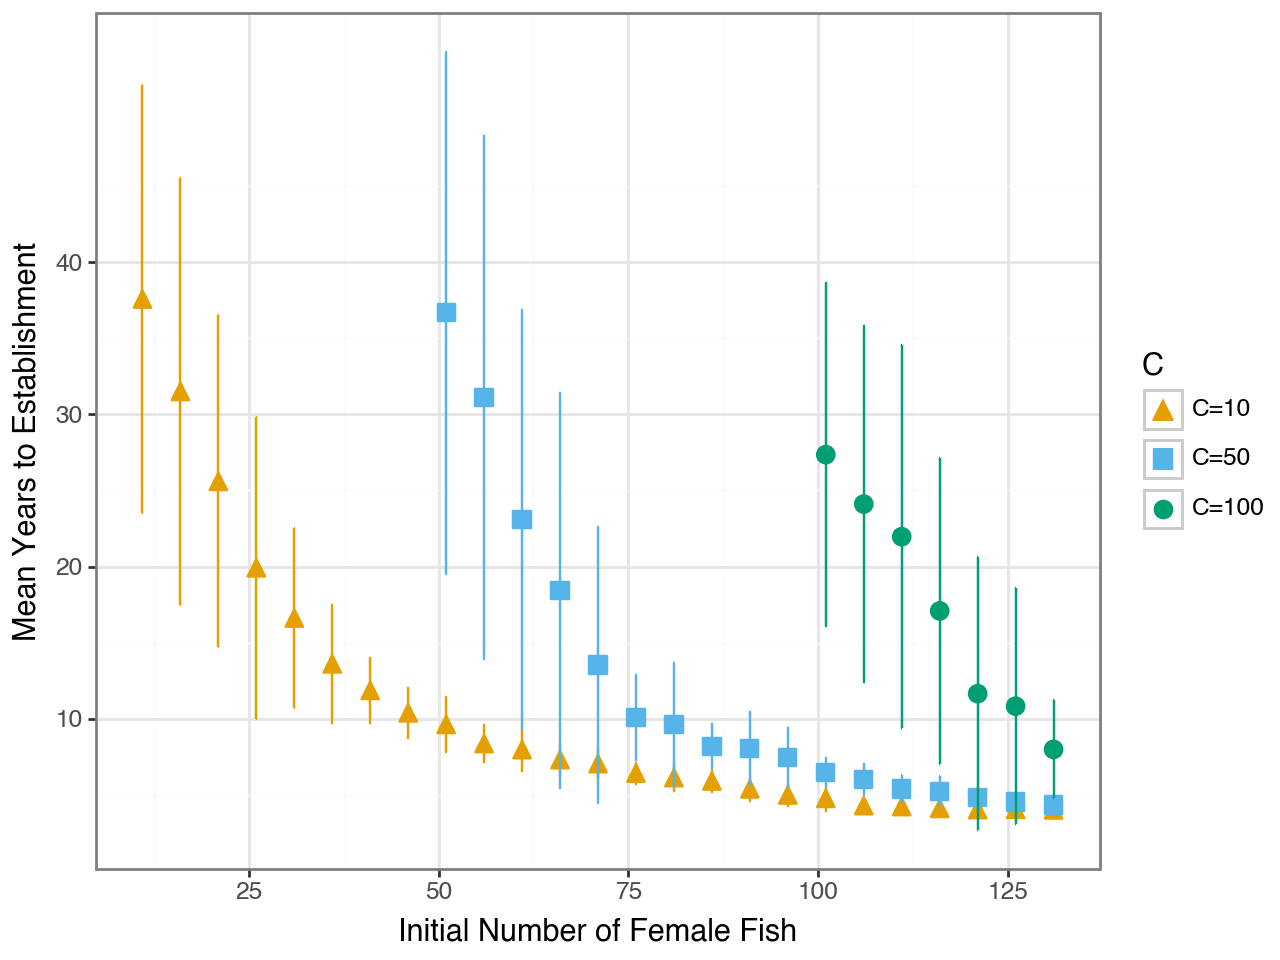

In [96]:
# Create a new DataFrame for plotting
plot_df = pd.DataFrame({
    'n0_fish': [result[0] for result in results],
    'C': [result[1] for result in results],
    'mean_time': [result[2] for result in results],
    'sd_time': [result[3] for result in results],
    'CImoe': [1.96 * (result[3]/np.sqrt(50)) for result in results]
})

C_mapping = {104.7: "C=10", 523.5: "C=50", 1047: "C=100"}
plot_df['C'] = plot_df['C'].map(C_mapping)

# Convert the 'C' column to a categorical type with specified levels
plot_df['C'] = pd.Categorical(plot_df['C'], categories=["C=10", "C=50", "C=100"], ordered=True)

# Filter the DataFrame to only include rows where n0_fish > C
plot_df_filtered = plot_df[plot_df.apply(lambda row: row['n0_fish'] > float(row['C'].split('=')[1]), axis=1)]

line_styles = ['dotted', 'dashed', 'solid']
markers = ['^', 's', 'o']
colorblind_palette = ["#E69F00", "#56B4E9", "#009E73"]
#colorblind_palette = ["#0072B2", "#D55E00", "#009E73"]  # Example colors

# Plot the results
plot = (
    p9.ggplot(plot_df_filtered, p9.aes(x='n0_fish', y='mean_time', color='C', shape='C')) +
    p9.geom_point(size=3, show_legend=True) +
    p9.geom_errorbar(p9.aes(ymin='mean_time - sd_time', ymax='mean_time + sd_time'), width=0.2, show_legend=False) +
    p9.scale_color_manual(values=colorblind_palette, breaks=["C=10", "C=50", "C=100"], labels=['C=10', 'C=50', 'C=100']) +
    p9.scale_shape_manual(values=markers, breaks=["C=10", "C=50", "C=100"], labels=['C=10', 'C=50', 'C=100']) +
    p9.labs(
        x="Initial Number of Female Fish",
        y="Mean Years to Establishment"
    ) +
    p9.scale_x_continuous(breaks=range(0, int(plot_df_filtered['n0_fish'].max()) + 25, 25)) +  # Set x-axis ticks every 25
    p9.scale_y_continuous(breaks=range(0, int(plot_df_filtered['mean_time'].max()) + 10, 10)) +  # Set y-axis ticks every 10
    p9.theme_bw() +
    p9.theme(legend_title=p9.element_blank(),
             axis_title_x=p9.element_text(size=12), 
             axis_title_y=p9.element_text(size=12))+
    p9.theme_bw() 
)

plot.show()

In [97]:
plot.save("figures/time2E.png", dpi=300)

/Users/jpeirce/miniconda3/lib/python3.10/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/jpeirce/miniconda3/lib/python3.10/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: figures/time2E.png


In [98]:
plot_df

,n0_fish,C,mean_time,sd_time,CImoe
0,1,C=10,16.500000,19.562464,5.422438
1,6,C=10,38.760000,16.157426,4.478610
2,11,C=10,37.583333,14.072481,3.900693
3,16,C=10,31.510638,14.033201,3.889805
4,21,C=10,25.595745,10.912923,3.024908
...,...,...,...,...,...
76,111,C=100,21.960000,12.598349,3.492084
77,116,C=100,17.080000,10.047567,2.785043
78,121,C=100,11.640000,8.979443,2.488975
79,126,C=100,10.820000,7.765797,2.152569


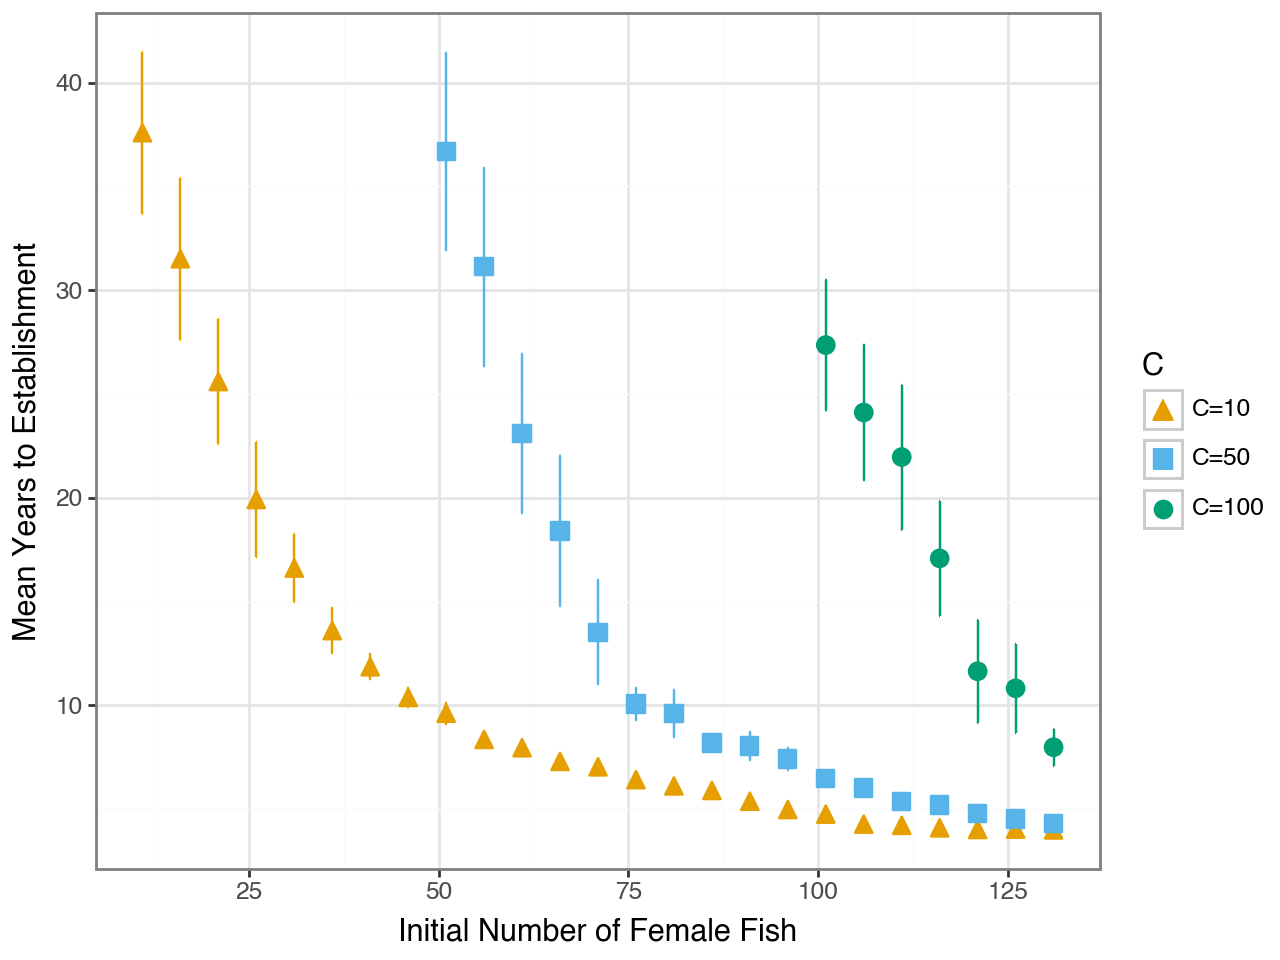

In [99]:
# Plot the results with 95% CI error bars
plot = (
    p9.ggplot(plot_df_filtered, p9.aes(x='n0_fish', y='mean_time', color='C', shape='C')) +
    p9.geom_point(size=3, show_legend=True) +
    p9.geom_errorbar(p9.aes(ymin='mean_time - CImoe', ymax='mean_time + CImoe'), width=0.2, show_legend=False) +
    p9.scale_color_manual(values=colorblind_palette, breaks=["C=10", "C=50", "C=100"], labels=['C=10', 'C=50', 'C=100']) +
    p9.scale_shape_manual(values=markers, breaks=["C=10", "C=50", "C=100"], labels=['C=10', 'C=50', 'C=100']) +
    p9.labs(
        x="Initial Number of Female Fish",
        y="Mean Years to Establishment"
    ) +
    p9.scale_x_continuous(breaks=range(0, int(plot_df_filtered['n0_fish'].max()) + 25, 25)) +  # Set x-axis ticks every 25
    p9.scale_y_continuous(breaks=range(0, int(plot_df_filtered['mean_time'].max()) + 10, 10)) +  # Set y-axis ticks every 10
    p9.theme_bw() +
    p9.theme(legend_title=p9.element_blank(),
             axis_title_x=p9.element_text(size=12), 
             axis_title_y=p9.element_text(size=12))+
    p9.theme_bw() 
)

plot.show()

## Session Info

Lastly, we print the session information to create reproducilbe result:

In [1]:
import sys
print(sys.version)

3.10.13 (main, Sep 11 2023, 08:24:56) [Clang 14.0.6 ]


In [53]:
!conda list

# packages in environment at /Users/jpeirce/miniconda3/envs/myenv:
#
# Name                    Version                   Build  Channel
_tflow_select             2.2.0                     eigen  
abseil-cpp                20211102.0           hc377ac9_0  
absl-py                   2.1.0           py310hca03da5_0  
aiohappyeyeballs          2.4.0           py310hca03da5_0  
aiohttp                   3.10.5          py310h80987f9_0  
aiosignal                 1.2.0              pyhd3eb1b0_0  
anyio                     4.2.0           py310hca03da5_0  
appnope                   0.1.2           py310hca03da5_1001  
argon2-cffi               21.3.0             pyhd3eb1b0_0  
argon2-cffi-bindings      21.2.0          py310h1a28f6b_0  
asttokens                 2.0.5              pyhd3eb1b0_0  
astunparse                1.6.3                      py_0  
async-lru                 2.0.4           py310hca03da5_0  
async-timeout             4.0.3           py310hca03da5_0  
attrs                